# Analyse Exploratoire Kickstarter

## Problématique

**Comment tirer parti de la donnée de crowdfunding pour aider les entrepreneurs à atteindre leur Product-Market Fit ?**

C'est l'objet de notre étude qui vise à modéliser les facteurs de sur-performance de plus de 200 000 campagnes Kickstarter afin d'isoler les leviers opérationnels du Product-Market Fit.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

kickstarter_df = pd.read_csv('/Users/mariamalaborde/Documents/DataScientest/memoire-2026/data/clean_kickstarter.csv', sep=',', encoding='utf-8')

kickstarter_df.head(3)

,id,name,blurb,state,created_at,launched_at,deadline,duration_days,prep_days,launch_month,...,country,region,has_video,staff_pick,spotlight,name_len_words,name_len_char,blurb_len_char,blurb_len_words,blurb_density
0,13583,American Dream # 1 | 31 Pages of Full Color He...,A heroine's first day on the job uncovers a te...,successful,2023-04-02 16:35:40,2024-09-04 13:59:04,2024-11-03 14:59:04,60,520,September,...,US,Amérique du Nord,True,False,True,12,57,97,17,5.71
1,18520,Grandma's are Life,Raising money to help my grandmother recover f...,failed,2016-10-19 12:13:18,2016-10-19 13:32:40,2016-11-18 14:32:40,30,0,October,...,US,Amérique du Nord,False,False,False,3,18,135,24,5.62
2,19685,Pumpkin & Friends: Soft & Silly Plush Pals!,"The cute, soft, and huggable plushies are read...",successful,2024-04-08 19:45:55,2024-05-14 17:31:01,2024-06-28 17:31:01,45,35,May,...,US,Amérique du Nord,False,False,True,8,43,58,10,5.80


In [2]:
kickstarter_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 201431 entries, 0 to 201430
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      201431 non-null  int64  
 1   name                    201431 non-null  str    
 2   blurb                   201431 non-null  str    
 3   state                   201431 non-null  str    
 4   created_at              201431 non-null  str    
 5   launched_at             201431 non-null  str    
 6   deadline                201431 non-null  str    
 7   duration_days           201431 non-null  int64  
 8   prep_days               201431 non-null  int64  
 9   launch_month            201431 non-null  str    
 10  launch_year             201431 non-null  int64  
 11  goal_eur                201431 non-null  float64
 12  pledged_eur             201431 non-null  float64
 13  percent_funded          201431 non-null  float64
 14  backers_count           201431 

## Performance

### Distribution du succès

--- Nombre de projets par statut ---
state
successful    119596
failed         69900
canceled        9172
live            2763
Name: count, dtype: int64

--- Pourcentage par statut ---
state
successful    59.37
failed        34.70
canceled       4.55
live           1.37
Name: proportion, dtype: float64


/var/folders/_p/kb4rf6557_z3pw5w_dd3n0nm0000gn/T/ipykernel_5937/2019640779.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.index, y=state_counts.values, palette='Greens_r')


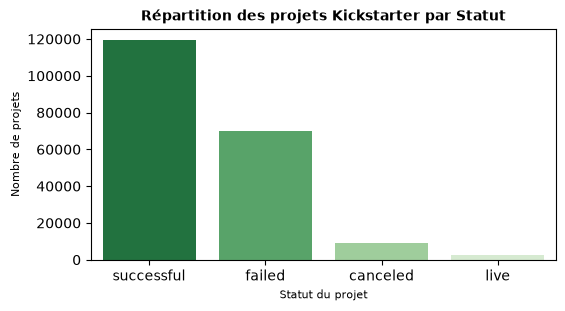

In [3]:
state_counts = kickstarter_df['state'].value_counts()
state_percent = kickstarter_df['state'].value_counts(normalize=True) * 100

print("--- Nombre de projets par statut ---")
print(state_counts)
print("\n--- Pourcentage par statut ---")
print(state_percent.round(2))

# Graphique en barre
plt.figure(figsize=(6, 3))
sns.barplot(x=state_counts.index, y=state_counts.values, palette='Greens_r')

# Titres et étiquettes
plt.title('Répartition des projets Kickstarter par Statut', fontsize=10, fontweight='bold')
plt.xlabel('Statut du projet', fontsize=8)
plt.ylabel('Nombre de projets', fontsize=8)

plt.show()

### Corrélation entre les variables numériques

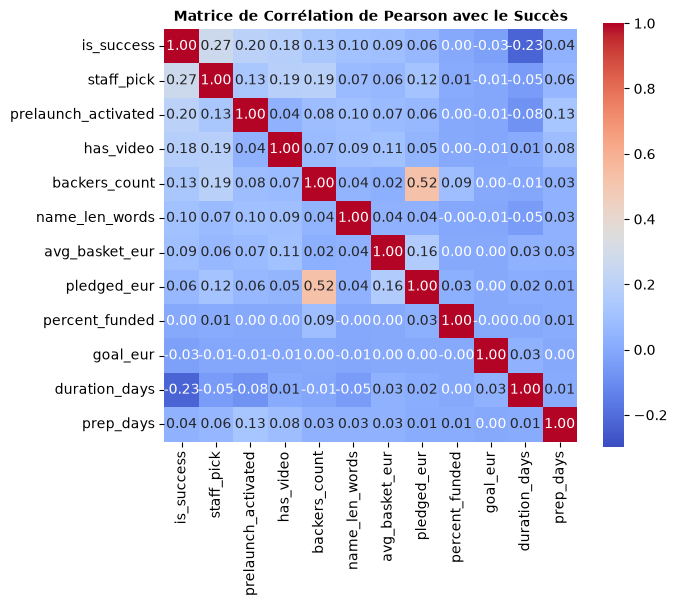

In [4]:
# Exclusion des projets live
df_completed = kickstarter_df[kickstarter_df['state'].isin(['successful', 'failed', 'canceled'])].copy()

# Variable de succès binaire
df_completed['is_success'] = (df_completed['state'] == 'successful').astype(int)

# Sélection des variables numériques à analyser
num_cols = [
    'is_success', 'staff_pick', 'prelaunch_activated', 'has_video', 
    'backers_count', 'name_len_words', 'avg_basket_eur', 
    'pledged_eur', 'percent_funded', 'goal_eur', 'duration_days', 'prep_days'
]

# Matrice de corrélation
corr = df_completed[num_cols].corr()

plt.figure(figsize=(7, 6))

sns.heatmap(
    corr, 
    annot=True,          # Affiche les valeurs numériques dans chaque case
    fmt=".2f",           # Arrondit à 2 décimales
    cmap="coolwarm",     # Palette de couleur (Rouge = positif, Bleu = négatif)
    vmin=-0.3, vmax=1.0, # Échelle de couleur
    square=True
)

plt.title("Matrice de Corrélation de Pearson avec le Succès", fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

D'après cette matrice, les 3 grands moteurs de succès sont :
* `staff_pick` : Preuve sociale et highlight
* `prelaunch_activated` : Une page de pré-lancement a été configurée.
* `has_video` : Une vidéo a été mise en ligne.

En revanche, on a un frein :
* `duration_days` : On peut supposer que plus une campagne est longue, moins il y a ce sentiment d'urgence.

Une autre corrélation à noter, hors-succès :
* Entre `backers_count` et `pledged_eur` : Plus on a de contributeurs, plus le montant récolté est élevé.

### Corrélation entre les variables qualitatives

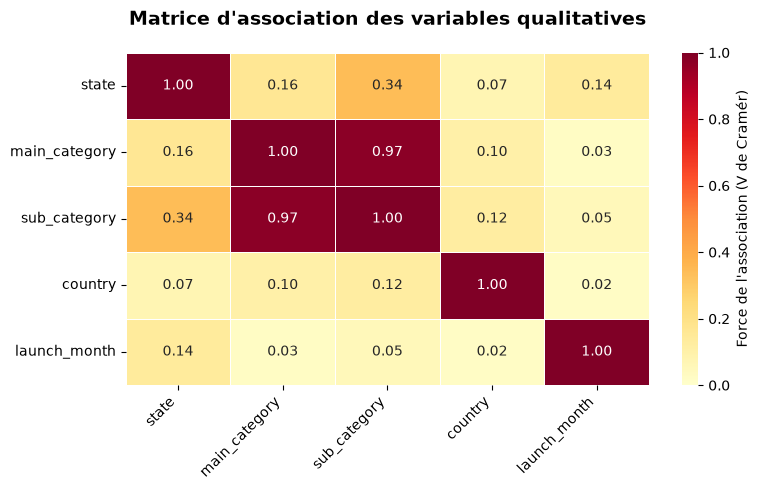

In [5]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Calcule le V de Cramér entre deux variables qualitatives."""
    # Création du tableau croisé (contingence)
    confusion_matrix = pd.crosstab(x, y)
    
    # Calcul du Chi-2
    chi2 = chi2_contingency(confusion_matrix)[0]
    
    # Récupération du nombre total d'observations (n)
    n = confusion_matrix.sum().sum()
    
    # Récupération des dimensions (lignes et colonnes)
    r, c = confusion_matrix.shape
    
    # Application de la formule
    return np.sqrt(chi2 / (n * min(r - 1, c - 1)))

# 2. Sélection des variables qualitatives à tester
# N'hésite pas à ajouter ou retirer des colonnes selon tes besoins
colonnes_quali = ['state', 'main_category', 'sub_category', 'country', 'launch_month']

# Création d'un sous-dataset propre (sans valeurs manquantes)
df_quali = kickstarter_df[colonnes_quali].dropna().copy()

# 3. Initialisation d'une matrice vide
cramer_matrix = pd.DataFrame(index=colonnes_quali, columns=colonnes_quali)

# 4. Remplissage de la matrice avec notre fonction
for col1 in colonnes_quali:
    for col2 in colonnes_quali:
        # On calcule le score pour chaque paire possible
        cramer_matrix.loc[col1, col2] = cramers_v(df_quali[col1], df_quali[col2])

# Conversion obligatoire en format numérique pour que Seaborn puisse l'afficher
cramer_matrix = cramer_matrix.astype(float)

# Affichage de la Matrice 
plt.figure(figsize=(8, 5))

sns.heatmap(
    cramer_matrix, 
    annot=True,            # Affiche les scores directement dans les cases
    fmt=".2f",             # Arrondit à 2 chiffres après la virgule
    cmap="YlOrRd",         # Palette de couleurs allant du jaune au rouge foncé
    vmin=0, vmax=1,        # L'échelle du V de Cramér est fixée entre 0 et 1
    linewidths=0.5,        # Lignes séparatrices pour la lisibilité
    cbar_kws={'label': 'Force de l\'association (V de Cramér)'}
)

plt.title("Matrice d'association des variables qualitatives", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

D'après cette matrice d'association, la sous-catégorie semble avoir plus d'influence sur le succès que la catégorie principale. En revanche, l'influence du mois de lancement et du pays de lancement est limitée.

## Finances

### Analyse des objectifs financiers
* Existe-t-il un "seuil critique" au-delà duquel le taux de succès chute drastiquement ?
* Comparaison de la médiane de goal_eur entre succès et échecs.

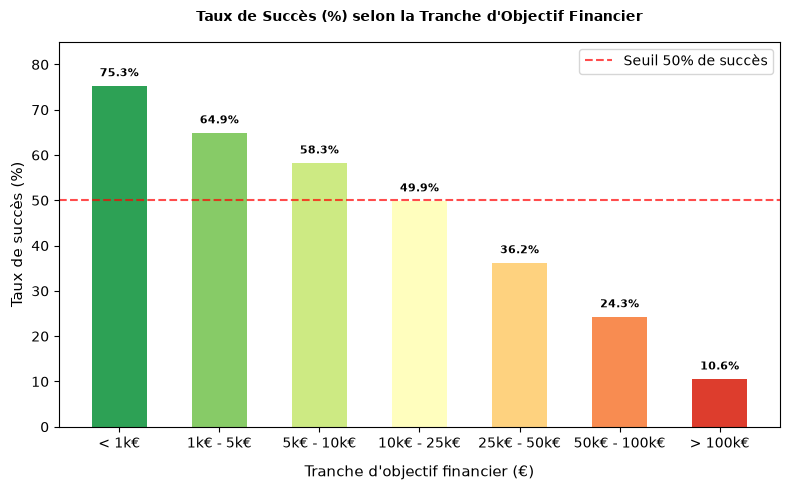

In [6]:
# Évaluer si il existe un seuil
import numpy as np

# Tranches d'objectifs
bins = [0, 1000, 5000, 10000, 25000, 50000, 100000, np.inf]
labels = ['< 1k€', '1k€ - 5k€', '5k€ - 10k€', '10k€ - 25k€', '25k€ - 50k€', '50k€ - 100k€', '> 100k€']

df_completed['goal_bin'] = pd.cut(df_completed['goal_eur'], bins=bins, labels=labels)

# Taux de succès (%) par tranche
success_rate = df_completed.groupby('goal_bin', observed=False)['is_success'].mean() * 100


colors = sns.color_palette('RdYlGn_r', len(success_rate))
plt.figure(figsize=(8, 5))

bars = plt.bar(
    success_rate.index, success_rate.values, color=colors, width=0.55
)

plt.title(
    "Taux de Succès (%) selon la Tranche d'Objectif Financier",
    fontsize=10,
    fontweight='bold',
    pad=15,
)
plt.xlabel("Tranche d'objectif financier (€)", fontsize=11, labelpad=10)
plt.ylabel('Taux de succès (%)', fontsize=11)

# Agrandir l'axe Y pour laisser de la place aux étiquettes
plt.ylim(0, 85)

# Ligne horizontale du seuil de 50%
plt.axhline(
    50, color='red', linestyle='--', alpha=0.7, label='Seuil 50% de succès'
)

# 5. Affichage des pourcentages bien au-dessus de chaque barre
for bar in bars:
  height = bar.get_height()
  plt.annotate(
      f'{height:.1f}%',
      xy=(bar.get_x() + bar.get_width() / 2, height + 1.5),
      ha='center',
      va='bottom',
      fontsize=8,
      fontweight='bold',
  )

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

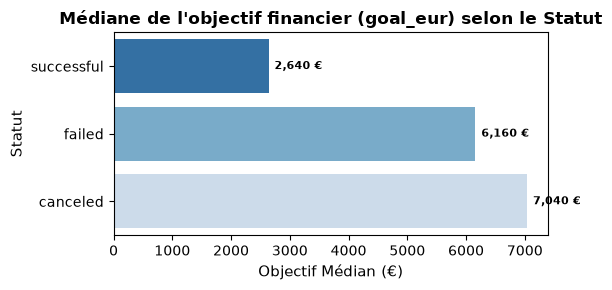

In [7]:
# Évaluer la médiane d'objectif financieier 
goal_medians = df_completed.groupby('state')['goal_eur'].median().reindex(['successful', 'failed', 'canceled'])

plt.figure(figsize=(6, 3))
ax = sns.barplot(x=goal_medians.values, y=goal_medians.index, palette='Blues_r', hue=goal_medians.index, legend=False)

plt.title("Médiane de l'objectif financier (goal_eur) selon le Statut", fontsize=12, fontweight='bold')
plt.xlabel("Objectif Médian (€)", fontsize=11)
plt.ylabel("Statut", fontsize=11)

# Ajouter les montants exacts sur les barres
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:,.0f} €', (width + 100, p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

D'après ces deux graphiques, on peut en conclure que plus l'objectif est élevé, moins la campagne a de chances de réussir.

* Les projets demandant moins de 1 000 € réussissent dans 3 cas sur 4 (75,3 %).
* À l'inverse, les projets ambitieux demandant plus de 100 000 € échouent à près de 90 % du temps.
* Il semble exister un seuil aux alentours des 25 000 €. En dessous de 25k€, le taux de succès reste égal ou supérieur à 50 %.
* Au-delà de 25k€, le taux de succès chute brutalement à 36,2 %, puis dégringole.

### Sur-performance et atteinte de l'objectif
* Distribution du taux de financement : détecter les outliers.

In [8]:
# Création d'une variable pour définir la sur-performance

import numpy as np

def categorize_performance(row):
    # Si le projet a échoué ou est annulé
    if row['state'] in ['failed', 'canceled']:
        return "Non financé <100%"
    # Si le projet est encore en cours
    elif row['state'] == 'live':
        return "En cours"
    # Si le projet est un succès, on le classe selon son percent_funded
    elif row['state'] == 'successful':
        pf = row['percent_funded']
        if pf < 105:
            return "Tout juste 100-105%"
        elif pf < 200:
            return "Modérée 105-200%"
        elif pf < 500:
            return "Solide 200-500%"
        elif pf < 1000:
            return "Très forte 500-1000%"
        else:
            return "Super-funded >1000%"
    return "Autre"

# Application de la fonction pour créer la nouvelle colonne
kickstarter_df['performance_tier'] = kickstarter_df.apply(categorize_performance, axis=1)

# Vérification du résultat
print(kickstarter_df['performance_tier'].value_counts().sort_index())

performance_tier
En cours                 2763
Modérée 105-200%        57093
Non financé <100%       79072
Solide 200-500%         17969
Super-funded >1000%     10264
Tout juste 100-105%     26519
Très forte 500-1000%     7751
Name: count, dtype: int64


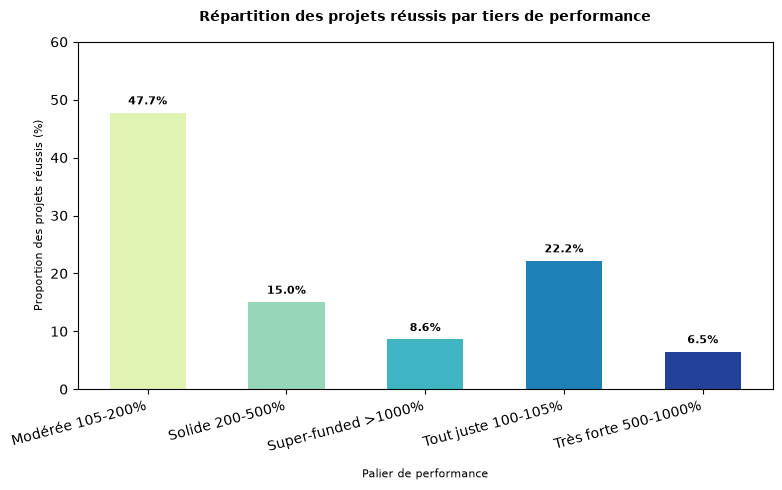

In [9]:
# Distribution des tiers de performances
# Filtre des projets réussis
df_success = kickstarter_df[kickstarter_df['state'] == 'successful'].copy()

tier_counts = df_success['performance_tier'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(8, 5))
colors = sns.color_palette("YlGnBu", len(tier_counts))
bars = plt.bar(tier_counts.index, tier_counts.values, color=colors, width=0.55)

plt.title("Répartition des projets réussis par tiers de performance", fontsize=10, fontweight='bold', pad=15)
plt.xlabel("Palier de performance", fontsize=8, labelpad=10)
plt.ylabel("Proportion des projets réussis (%)", fontsize=8)
plt.ylim(0, 60) # Laisser de l'espace en haut pour les étiquettes

for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f'{height:.1f}%',
        xy=(bar.get_x() + bar.get_width() / 2, height + 1),
        ha='center', va='bottom', fontsize=8, fontweight='bold'
    )
    
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.show()

In [10]:
super_funded_df = kickstarter_df[kickstarter_df['performance_tier'] == 'Super-funded > 1000%'].copy()

# Tri
super_funded_df = super_funded_df.sort_values(by='percent_funded', ascending=False)

colonnes_super_funded = [
    'name', 
    'main_category', 
    'goal_eur', 
    'pledged_eur', 
    'percent_funded'
]

print("--- TOP 15 DES PROJETS SUPER-FUNDED ---")
display(super_funded_df[colonnes_super_funded].head(15))

--- TOP 15 DES PROJETS SUPER-FUNDED ---


,name,main_category,goal_eur,pledged_eur,percent_funded


### Analyse des fonds collectés
* Volume total récolté sur la plateforme et médiane des montants levés.

In [11]:
volume_total = kickstarter_df['pledged_eur'].sum()
mediane_globale = kickstarter_df['pledged_eur'].median()
moyenne_globale = kickstarter_df['pledged_eur'].mean()

volume_success = df_success['pledged_eur'].sum()
mediane_success = df_success['pledged_eur'].median()
moyenne_success = df_success['pledged_eur'].mean()

print(f"Volume total récolté sur la plateforme : {volume_total:,.0f} €")
print(f"Médiane globale des montants levés : {mediane_globale:,.0f} €")
print(f"Moyenne globale des montants levés : {moyenne_globale:,.0f} €")
print("------------------------------------------------")
print(f"Volume récolté (uniquement projets réussis) : {volume_success:,.0f} €")
print(f"Médiane des levées (uniquement projets réussis) : {mediane_success:,.0f} €")
print(f"Moyenne des levées (uniquement projets réussis) : {moyenne_success:,.0f} €")

Volume total récolté sur la plateforme : 2,947,266,707 €
Médiane globale des montants levés : 1,617 €
Moyenne globale des montants levés : 14,632 €
------------------------------------------------
Volume récolté (uniquement projets réussis) : 2,800,687,212 €
Médiane des levées (uniquement projets réussis) : 4,452 €
Moyenne des levées (uniquement projets réussis) : 23,418 €


On constate une grande différence entre médiane et moyenne, ce qui indique de très grandes disparités de levées de fonds. On va donc se concentrer sur la médiane qui se rapproche de la réalité du plus grand nombre de projets.

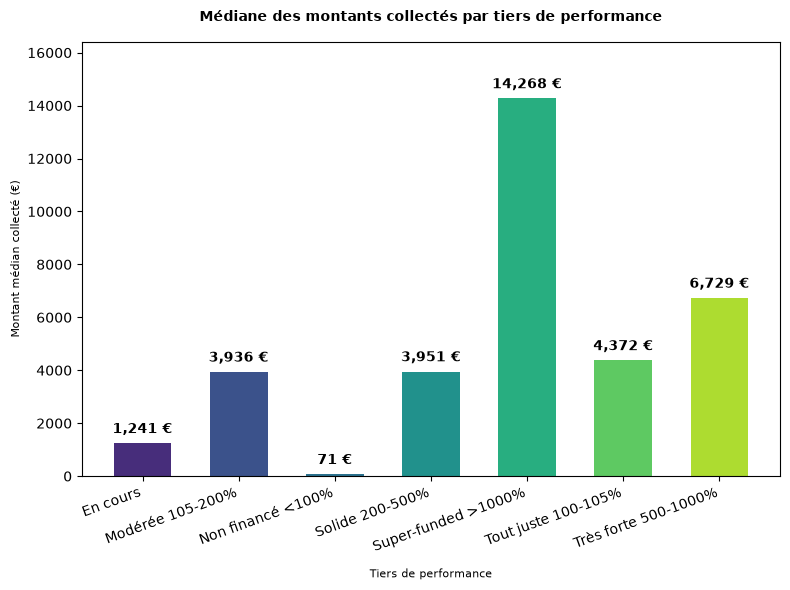

In [12]:
# Distribution de la médiane par tiers de performance
median_by_tier = kickstarter_df.groupby('performance_tier')['pledged_eur'].median().sort_index()

# Graphique
plt.figure(figsize=(8, 6))
colors = sns.color_palette("viridis", len(median_by_tier))
bars = plt.bar(median_by_tier.index, median_by_tier.values, color=colors, width=0.6)

plt.title("Médiane des montants collectés par tiers de performance", fontsize=10, fontweight='bold', pad=15)
plt.xlabel("Tiers de performance", fontsize=8, labelpad=10)
plt.ylabel("Montant médian collecté (€)", fontsize=8)


plt.ylim(0, median_by_tier.max() * 1.15)

for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f'{height:,.0f} €',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),  # Décalage de 5 points vers le haut
        textcoords="offset points",
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.show()

## Temporalité

### Évolution annuelle
* Tendance de croissance du nombre de projets et du volume financier au fil des ans.
* Évolution du taux de succès au fil du temps.

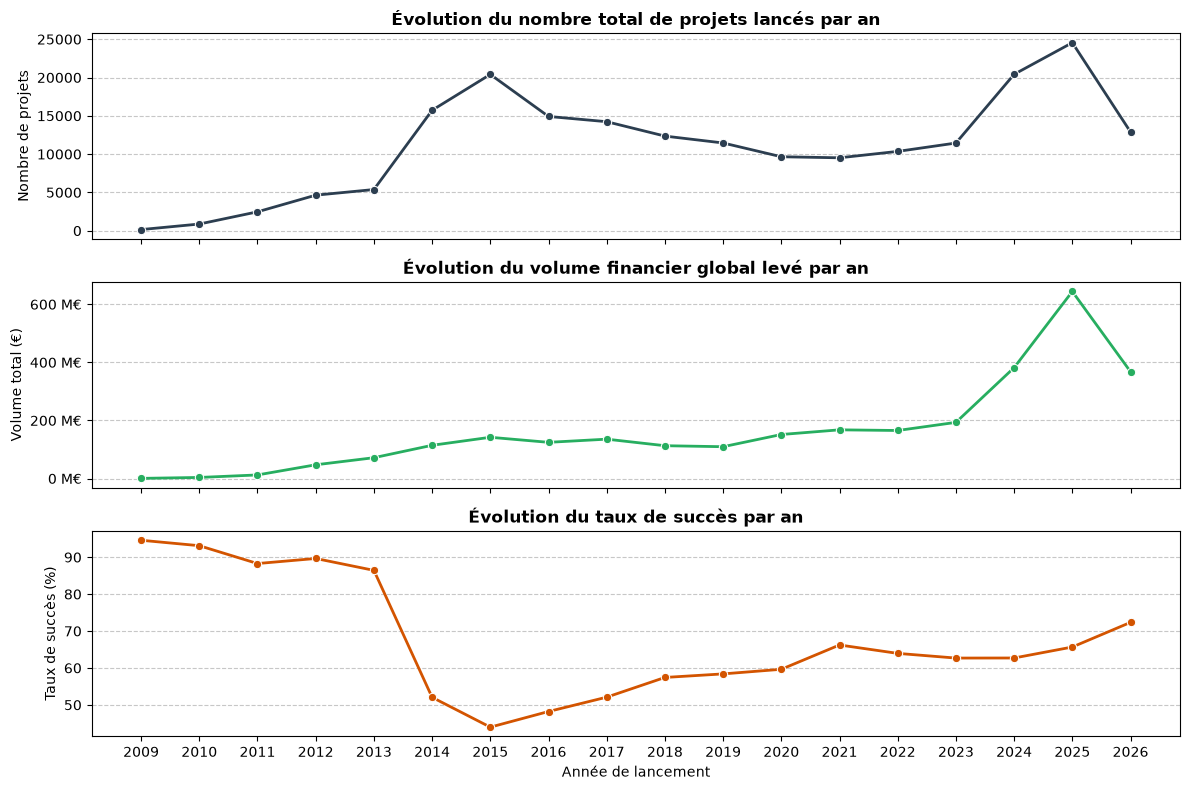

In [13]:
# Total projet par année et volume levé par année
yearly_global = kickstarter_df.groupby('launch_year').agg(
    num_projects=('name', 'count'),      # Nombre total de projets lancés
    total_volume=('pledged_eur', 'sum')  # Volume financier total levé
).reset_index()

# Taux de succès par année
yearly_success = df_completed.groupby('launch_year').agg(
    success_rate=('is_success', lambda x: x.mean() * 100)
).reset_index()

# Fusion des statistiques
yearly_stats = pd.merge(yearly_global, yearly_success, on='launch_year', how='left')

# Graphiques
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Graphique 1 : Nombre total de projets
sns.lineplot(data=yearly_stats, x='launch_year', y='num_projects', ax=axes[0], color='#2c3e50', marker='o', linewidth=2)
axes[0].set_title("Évolution du nombre total de projets lancés par an", fontweight='bold')
axes[0].set_ylabel("Nombre de projets")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Graphique 2 : Volume financier global
sns.lineplot(data=yearly_stats, x='launch_year', y='total_volume', ax=axes[1], color='#27ae60', marker='o', linewidth=2)
axes[1].set_title("Évolution du volume financier global levé par an", fontweight='bold')
axes[1].set_ylabel("Volume total (€)")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
# Formatage en millions d'euros
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,} M€".format(int(x/1e6))))

# Graphique 3 : Taux de succès
sns.lineplot(data=yearly_stats, x='launch_year', y='success_rate', ax=axes[2], color='#d35400', marker='o', linewidth=2)
axes[2].set_title("Évolution du taux de succès par an", fontweight='bold')
axes[2].set_ylabel("Taux de succès (%)")
axes[2].set_xlabel("Année de lancement")
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

# Affichage des années sans décimales
axes[2].set_xticks(yearly_stats['launch_year'])

plt.tight_layout()
plt.show()

En regardant ces trois graphiques, on voit une correction assez nette du taux de réussite entre 2013 et 2015. Le marché de Kickstarter a gagné en maturité. Depuis 2023, le volume financier levé a connu une nette hausse qui semble corrélée à l'augmentation du nombre de projets lancés ; cela dit, le taux de succès reste plutôt stable, avec une tendance haussière assez timide depuis 2024.

L'année 2026 n'est pas encore terminée donc il est impossible d'en savoir plus, mais la tendance est haussière ce qui devrait encourager les entrepreneurs et les start-ups à tester leurs idées sur la plateforme.

### Saisonnalité
* Y a-t-il un "meilleur mois" pour lancer un projet (taux de succès + volume) ?

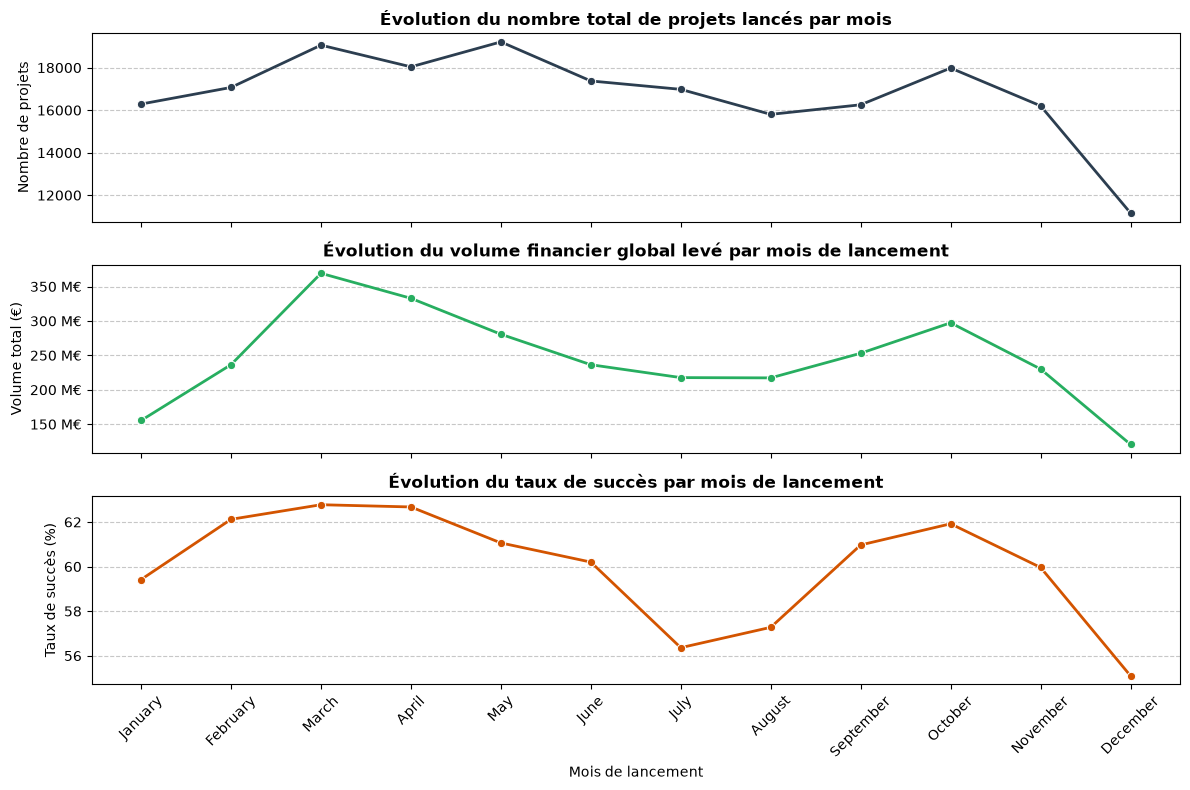

launch_month
January      16288
February     17070
March        19060
April        18039
May          19213
June         17375
July         16980
August       15803
September    16254
October      17983
November     16204
December     11162
Name: count, dtype: int64


In [14]:
# Ordre chronologique exact
ordre_mois = ['January', 'February', 'March', 'April', 'May', 'June', 
              'July', 'August', 'September', 'October', 'November', 'December']

# Forcer cet ordre logique
kickstarter_df['launch_month'] = pd.Categorical(kickstarter_df['launch_month'], categories=ordre_mois, ordered=True)

monthly_global = kickstarter_df.groupby('launch_month', observed=False).agg(
    num_projects=('name', 'count'),      
    total_volume=('pledged_eur', 'sum')  
).reset_index()

monthly_success = df_completed.groupby('launch_month', observed=False).agg(
    success_rate=('is_success', lambda x: x.mean() * 100)
).reset_index()

monthly_stats = pd.merge(monthly_global, monthly_success, on='launch_month', how='left')

# Graphiques
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Graphique 1 : Nombre total de projets par mois
sns.lineplot(data=monthly_stats, x='launch_month', y='num_projects', ax=axes[0], color='#2c3e50', marker='o', linewidth=2)
axes[0].set_title("Évolution du nombre total de projets lancés par mois", fontweight='bold')
axes[0].set_ylabel("Nombre de projets")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Graphique 2 : Volume financier global par mois
sns.lineplot(data=monthly_stats, x='launch_month', y='total_volume', ax=axes[1], color='#27ae60', marker='o', linewidth=2)
axes[1].set_title("Évolution du volume financier global levé par mois de lancement", fontweight='bold')
axes[1].set_ylabel("Volume total (€)")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,} M€".format(int(x/1e6))))

# Graphique 3 : Taux de succès par mois
sns.lineplot(data=monthly_stats, x='launch_month', y='success_rate', ax=axes[2], color='#d35400', marker='o', linewidth=2)
axes[2].set_title("Évolution du taux de succès par mois de lancement", fontweight='bold')
axes[2].set_ylabel("Taux de succès (%)")
axes[2].set_xlabel("Mois de lancement")
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

# Incliner légèrement les mois pour que ce soit parfait visuellement
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(kickstarter_df['launch_month'].value_counts().sort_index())

A priori, lancer sa campagne pendant les vacances de Noël (Décembre - Janvier) et pendant les vacances d'été (Juillet - Août) n'est pas recommandé car le taux de succès et le volume levé chute durant ces périodes. Il est important de noter que le nombre de projets lancés durant ces périodes chute également (sauf en Juillet) donc à prendre avec un grain de sel, mais si on ne souhaite vraiment pas prendre de risque, il vaut mieux éviter ces périodes.

### Durée de la campagne
* Est-ce que les campagnes plus courtes (ex: 30 jours) réussissent mieux que les campagnes longues (ex: 60 jours) ?

### Phase de préparation
* Prendre du temps pour préparer sa page (created_at à launched_at) augmente-t-il les chances de succès ?

## Communauté

### Engagement des contributeurs
* Combien de personnes soutiennent un projet en moyenne selon le statut ?

### Panier moyen
* Les projets financés s'appuient-ils sur beaucoup de petits donateurs ou sur quelques gros contributeurs ?

### Typologie des soutiens
* Répartition et taux de succès selon le profil de contribution (Micro-mécénat, Acheteur requis, etc.).

## Catégories de projets

### Performance par catégorie principale
* Top & Flop des catégories en termes de taux de succès et de fonds levés.

### Focus sous-catégorie
* Les sous-catégories à fort potentiel (celles qui dépassent largement leur médiane sectorielle cat_median_pledged_eur).

### Objectif vs Réalité par secteur
* Quelles catégories demandent les objectifs financiers les plus réalistes/élevés ?

## Géographie

### Répartition mondiale
* D'où viennent la majorité des projets (ex: Amérique du Nord vs Europe) ?

### Taux de succès géographique
* Certaines régions/pays performent-ils mieux que d'autres sur Kickstarter ?

## Signal et leviers marketing

### Media
* Impact direct de la vidéo explicative et de la phase de pré-lancement sur la réussite.

### Recommandation de Kickstarter
* L'effet "Coup de cœur Kickstarter" sur la conversion et la collecte.

### Optimisation du titre et de la description
* Impact de la longueur du nom et du blurb sur le taux de succès.

## Conclusion

### Apprentissages

### Recommandations stratégiques